In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
# 2. Load Dataset
df = pd.read_csv("health_claims .csv")

In [3]:
print(df.shape)

(20100, 30)


In [4]:
display(df.head())

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
0,67349080,XAI956194550,18874,2021-06-16,2021-05-01,2024-11-20,462337.48,28,Female,Houston,...,Rehab/Skilled Nursing,47,Inpatient,3440.06,824.59,0,16,939.08,True,False
1,85973291,XAI215993963,8762,2025-01-19,2025-01-17,2029-04-07,1883481.30,40,Other,Washington,...,Deceased,0,Outpatient,3618.40,851.43,0,6,170.40,False,True
2,62454860,XAI146653263,1920,2023-05-05,2023-03-24,2024-09-04,1500658.89,90,Female,Seattle,...,Deceased,0,Pharmacy,2442.41,616.23,0,2,549.38,True,False
3,58632240,XAI216596381,1316,2021-11-07,2021-11-02,2025-12-24,572237.61,49,Other,Fort Worth,...,Deceased,0,Pharmacy,587.78,459.33,0,2,396.49,False,True
4,96347311,XAI056900359,17039,2024-03-25,2024-02-18,2028-07-30,2088293.84,24,Female,New York,...,Deceased,0,Emergency Room,3047.55,847.40,0,15,865.87,True,False


In [5]:
display(df.tail())

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
20095,96935977,XAI044413092,6472,2024-03-12,2024-02-25,2025-11-05,1182670.52,9,Male,Jacksonville,...,Rehab/Skilled Nursing,0,Emergency Room,3961.31,973.40,0,5,441.98,False,True
20096,11620007,XAI604243002,878,2024-10-19,2024-09-07,2029-09-20,1225019.60,60,Other,Los Angeles,...,Against Medical Advice,58,Inpatient,3383.95,998.72,0,0,602.85,True,False
20097,71153195,XAI115939441,4913,2022-04-05,2022-02-28,2026-03-23,1320858.11,15,Other,Chicago,...,Home,0,Outpatient,18.69,713.95,0,5,585.15,True,True
20098,58683401,XAI213569144,13498,2024-10-04,2024-09-26,2028-11-03,484552.40,41,Other,New York,...,Transfer to another facility,0,Emergency Room,3165.91,761.46,0,11,338.57,False,False
20099,72839302,XAI771983990,12690,2024-09-30,2024-08-04,2025-07-28,166117.59,57,Female,San Antonio,...,Home,0,Laboratory,4177.15,769.07,0,13,931.32,True,False


In [6]:
df.info

<bound method DataFrame.info of        Patient_ID Policy_Number  Claim_ID  Claim_Date Service_Date  \
0        67349080  XAI956194550     18874  2021-06-16   2021-05-01   
1        85973291  XAI215993963      8762  2025-01-19   2025-01-17   
2        62454860  XAI146653263      1920  2023-05-05   2023-03-24   
3        58632240  XAI216596381      1316  2021-11-07   2021-11-02   
4        96347311  XAI056900359     17039  2024-03-25   2024-02-18   
...           ...           ...       ...         ...          ...   
20095    96935977  XAI044413092      6472  2024-03-12   2024-02-25   
20096    11620007  XAI604243002       878  2024-10-19   2024-09-07   
20097    71153195  XAI115939441      4913  2022-04-05   2022-02-28   
20098    58683401  XAI213569144     13498  2024-10-04   2024-09-26   
20099    72839302  XAI771983990     12690  2024-09-30   2024-08-04   

      Policy_Expiration_Date  Claim_Amount  Patient_Age Patient_Gender  \
0                 2024-11-20     462337.48           

In [7]:
df.describe

<bound method NDFrame.describe of        Patient_ID Policy_Number  Claim_ID  Claim_Date Service_Date  \
0        67349080  XAI956194550     18874  2021-06-16   2021-05-01   
1        85973291  XAI215993963      8762  2025-01-19   2025-01-17   
2        62454860  XAI146653263      1920  2023-05-05   2023-03-24   
3        58632240  XAI216596381      1316  2021-11-07   2021-11-02   
4        96347311  XAI056900359     17039  2024-03-25   2024-02-18   
...           ...           ...       ...         ...          ...   
20095    96935977  XAI044413092      6472  2024-03-12   2024-02-25   
20096    11620007  XAI604243002       878  2024-10-19   2024-09-07   
20097    71153195  XAI115939441      4913  2022-04-05   2022-02-28   
20098    58683401  XAI213569144     13498  2024-10-04   2024-09-26   
20099    72839302  XAI771983990     12690  2024-09-30   2024-08-04   

      Policy_Expiration_Date  Claim_Amount  Patient_Age Patient_Gender  \
0                 2024-11-20     462337.48         

In [8]:
print(df.isnull().sum())

Patient_ID                            0
Policy_Number                         0
Claim_ID                              0
Claim_Date                            0
Service_Date                          0
Policy_Expiration_Date                0
Claim_Amount                          0
Patient_Age                           0
Patient_Gender                        0
Patient_City                          0
Patient_State                         0
Hospital_ID                           0
Provider_Type                         0
Provider_Specialty                    0
Provider_City                         0
Provider_State                        0
Diagnosis_Code                        0
Procedure_Code                        0
Number_of_Procedures                  0
Admission_Type                        0
Discharge_Type                        0
Length_of_Stay_Days                   0
Service_Type                          0
Deductible_Amount                     0
CoPay_Amount                          0


In [9]:
df.describe()

,Patient_ID,Claim_ID,Claim_Amount,Patient_Age,Hospital_ID,Procedure_Code,Number_of_Procedures,Length_of_Stay_Days,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles
count,2.010000e+04,20100.000000,2.010000e+04,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000
mean,5.528158e+07,10005.580348,1.245349e+06,45.104925,500.204179,92463.849851,5.510249,4.975821,2508.487758,499.665796,0.000299,10.027910,499.480532
std,2.606038e+07,5774.135663,6.983001e+05,26.300942,288.437500,8151.470654,2.882847,13.239804,1443.579069,288.397727,0.017275,6.622332,289.745360
min,1.000265e+07,1.000000,5.516780e+03,0.000000,1.000000,71045.000000,1.000000,0.000000,0.030000,0.020000,0.000000,0.000000,0.020000
25%,3.266819e+07,5005.750000,6.674103e+05,22.000000,251.000000,93040.000000,3.000000,0.000000,1251.440000,248.800000,0.000000,5.000000,246.380000
50%,5.551009e+07,10008.500000,1.221707e+06,45.000000,500.000000,93571.000000,6.000000,0.000000,2508.875000,499.950000,0.000000,10.000000,498.410000
75%,7.814105e+07,15011.250000,1.835603e+06,68.000000,752.000000,99204.000000,8.000000,0.000000,3755.080000,750.040000,0.000000,15.000000,751.000000
max,9.998440e+07,20000.000000,2.499689e+06,90.000000,1000.000000,99284.000000,10.000000,60.000000,4999.870000,999.880000,1.000000,34.000000,999.980000


In [10]:
print(df["Is_Fraudulent"].value_counts())

Is_Fraudulent
False    15089
True      5011
Name: count, dtype: int64


In [11]:
df.duplicated().sum()

np.int64(28)

In [12]:
df[df.duplicated(keep=False)]

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
186,53180098,XAI538917766,3879,2022-10-29,2022-09-21,2023-06-11,997194.49,78,Other,San Antonio,...,Transfer to another facility,0,Outpatient,2541.24,251.78,0,2,607.95,True,True
415,98154126,XAI767579243,19731,2023-02-07,2023-02-06,2024-06-29,1078391.11,37,Female,Denver,...,Against Medical Advice,0,Emergency Room,4365.24,751.75,0,19,403.65,False,True
419,12386095,XAI919800117,17766,2023-12-21,2023-12-16,2027-02-14,1279349.32,36,Male,Washington,...,Against Medical Advice,0,Laboratory,31.36,743.35,0,15,905.50,False,True
871,48421255,XAI645951831,2673,2020-01-08,2019-12-21,2021-05-17,808182.71,33,Female,San Jose,...,Rehab/Skilled Nursing,41,Inpatient,1748.78,555.01,0,2,828.02,False,True
1008,98154126,XAI767579243,19731,2023-02-07,2023-02-06,2024-06-29,1078391.11,37,Female,Denver,...,Against Medical Advice,0,Emergency Room,4365.24,751.75,0,19,403.65,False,True
1028,82067354,XAI132510602,18528,2022-11-26,2022-09-21,2027-10-20,1380059.85,22,Male,Phoenix,...,Home,0,Emergency Room,2357.23,39.40,0,14,645.53,True,True
1470,42800624,XAI277537108,9003,2023-12-18,2023-11-30,2027-08-22,1335805.90,68,Male,Denver,...,Deceased,0,Laboratory,3970.72,907.73,0,9,997.12,False,True
1528,30139279,XAI867885360,565,2024-01-17,2023-10-29,2025-01-16,2093330.92,61,Female,San Diego,...,Deceased,0,Laboratory,2612.56,864.32,0,1,646.85,True,True
2112,82067354,XAI132510602,18528,2022-11-26,2022-09-21,2027-10-20,1380059.85,22,Male,Phoenix,...,Home,0,Emergency Room,2357.23,39.40,0,14,645.53,True,True
2259,95899111,XAI544434755,15955,2020-05-17,2020-04-09,2024-06-26,540027.94,76,Male,Houston,...,Rehab/Skilled Nursing,0,Emergency Room,3274.03,298.62,0,12,669.68,True,True


In [13]:
df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicates after removal: 0
New dataset shape: (20072, 30)


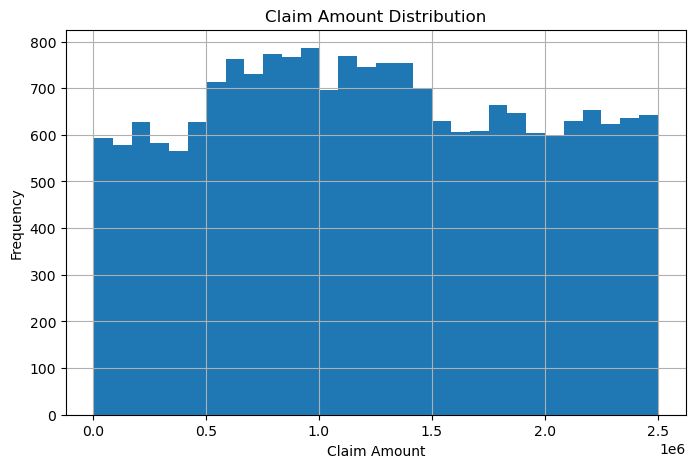

In [14]:
plt.figure(figsize=(8,5))
df['Claim_Amount'].hist(bins=30)
plt.title('Claim Amount Distribution')
plt.xlabel('Claim Amount')
plt.ylabel('Frequency')
plt.show()

<Figure size 800x500 with 0 Axes>

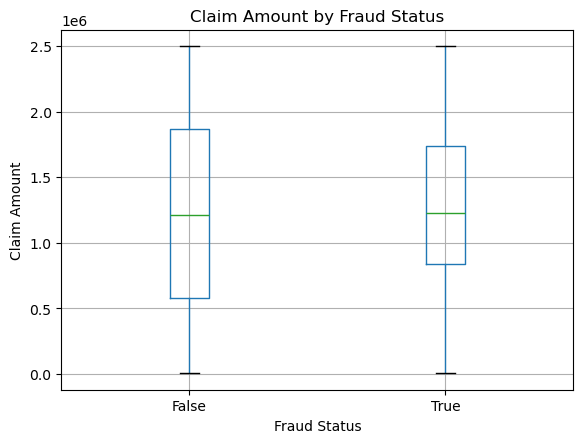

In [15]:
plt.figure(figsize=(8,5))

df.boxplot(column='Claim_Amount',
           by='Is_Fraudulent')

plt.title('Claim Amount by Fraud Status')
plt.suptitle('')
plt.xlabel('Fraud Status')
plt.ylabel('Claim Amount')
plt.show()

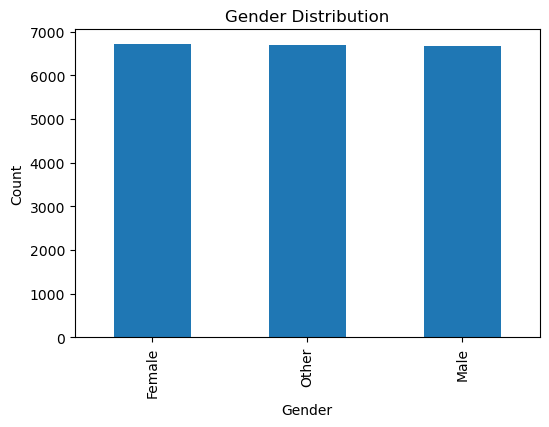

In [16]:
plt.figure(figsize=(6,4))

df['Patient_Gender'].value_counts().plot(kind='bar')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

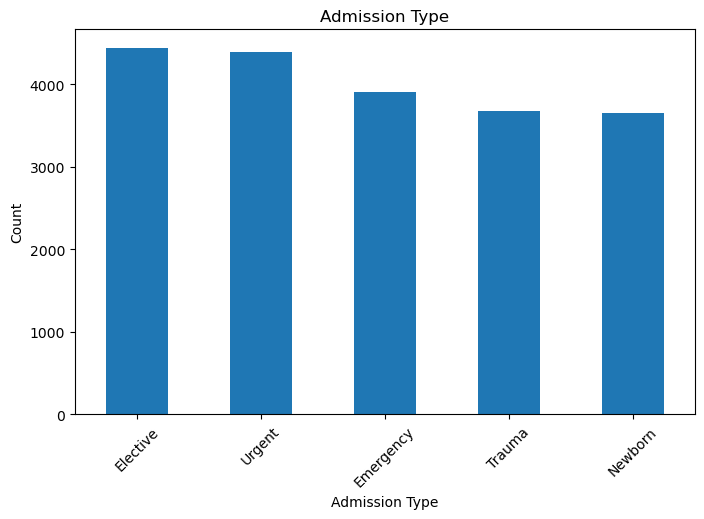

In [17]:
plt.figure(figsize=(8,5))

df['Admission_Type'].value_counts().plot(kind='bar')

plt.title('Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

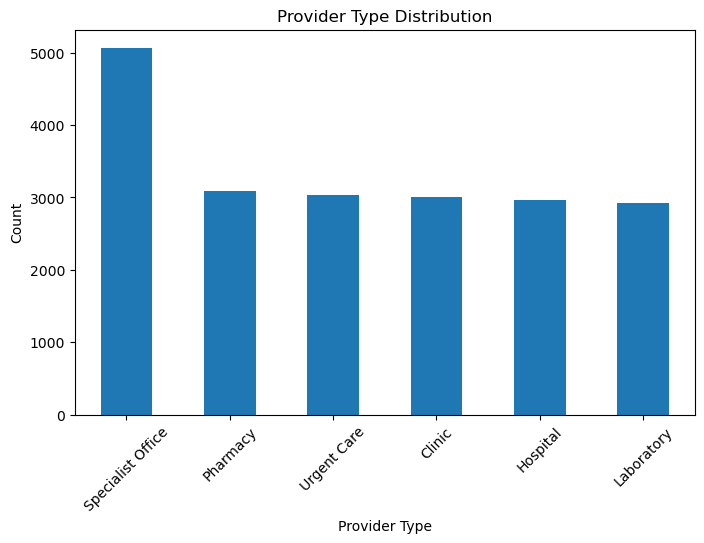

In [18]:
plt.figure(figsize=(8,5))

df['Provider_Type'].value_counts().plot(kind='bar')

plt.title('Provider Type Distribution')
plt.xlabel('Provider Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

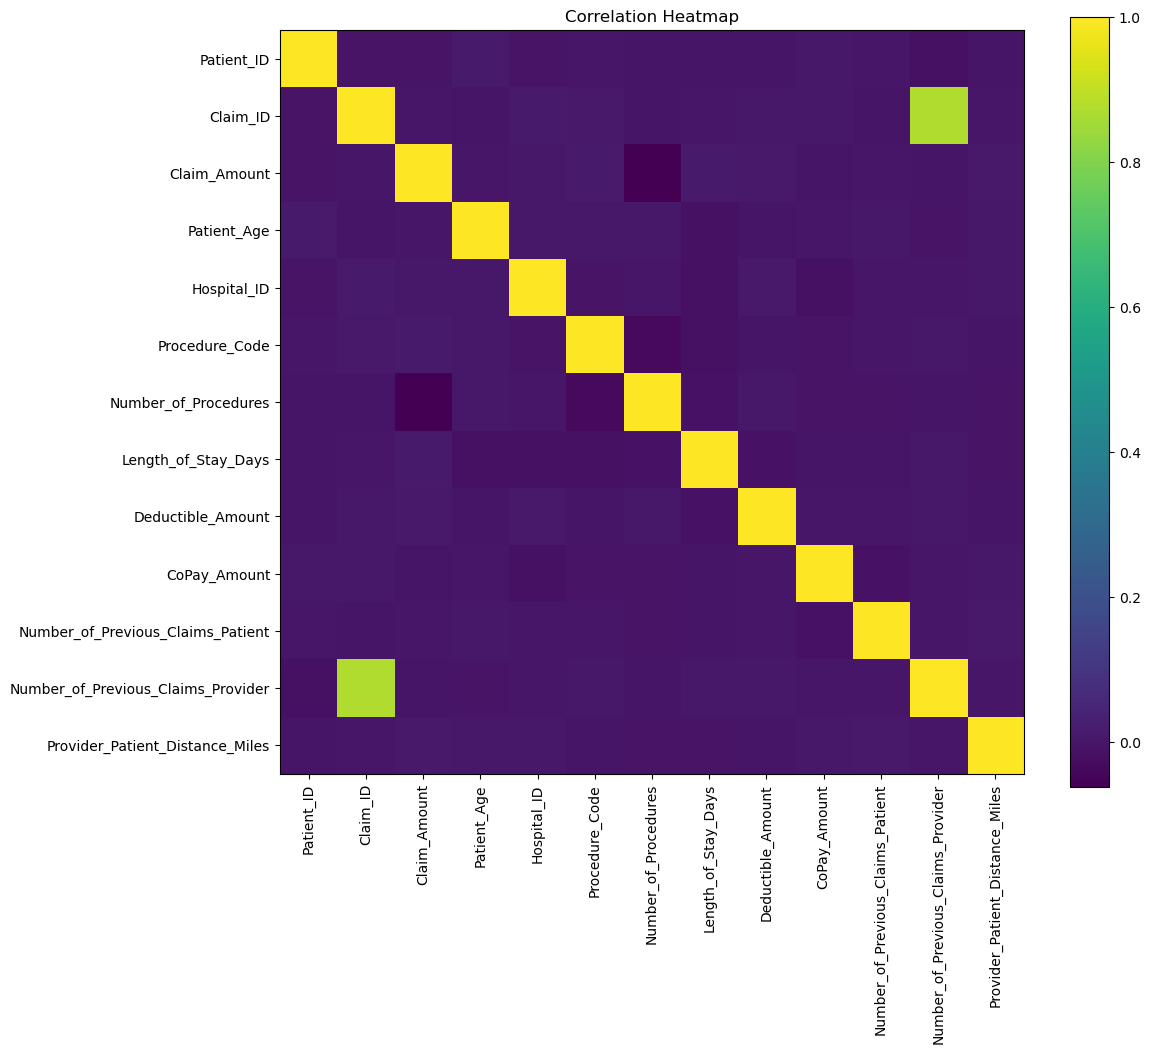

In [19]:
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(12,10))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title('Correlation Heatmap')

plt.show()

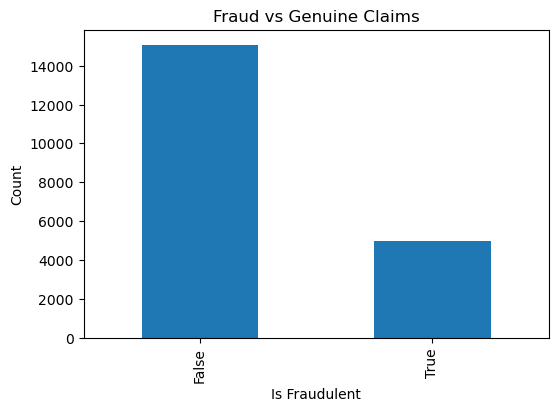

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['Is_Fraudulent'].value_counts().plot(kind='bar')
plt.title('Fraud vs Genuine Claims')
plt.xlabel('Is Fraudulent')
plt.ylabel('Count')
plt.show()

In [21]:
fraud_percentage = (5000 / 20000) * 100
print(fraud_percentage)

25.0


In [22]:
print(df['Is_Fraudulent'].value_counts())

print(df['Is_Fraudulent'].value_counts(normalize=True) * 100)

Is_Fraudulent
False    15089
True      4983
Name: count, dtype: int64
Is_Fraudulent
False    75.174372
True     24.825628
Name: proportion, dtype: float64


In [23]:
df.drop(columns=['Policy_Number'], inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_25552\3239440337.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Policy_Number'], inplace=True)


In [24]:
# Convert to datetime
df['Claim_Date'] = pd.to_datetime(df['Claim_Date'])
df['Service_Date'] = pd.to_datetime(df['Service_Date'])
df['Policy_Expiration_Date'] = pd.to_datetime(df['Policy_Expiration_Date'])

# Feature Engineering
df['Days_Between_Service_Claim'] = (
    df['Claim_Date'] - df['Service_Date']
).dt.days

df['Days_Until_Expiry'] = (
    df['Policy_Expiration_Date'] - df['Claim_Date']
).dt.days

# Drop original date columns
df.drop(
    columns=['Claim_Date',
             'Service_Date',
             'Policy_Expiration_Date'],
    inplace=True
)

C:\Users\user\AppData\Local\Temp\ipykernel_25552\2624483353.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Claim_Date'] = pd.to_datetime(df['Claim_Date'])
C:\Users\user\AppData\Local\Temp\ipykernel_25552\2624483353.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Service_Date'] = pd.to_datetime(df['Service_Date'])
C:\Users\user\AppData\Local\Temp\ipykernel_25552\2624483353.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [25]:
X = df.drop('Is_Fraudulent', axis=1)
y = df['Is_Fraudulent']

In [26]:
X = pd.get_dummies(X, drop_first=True)

In [27]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print(X_train.isnull().sum().sum())

0


In [30]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_smote, y_train_smote = sm.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Is_Fraudulent
False    12071
True      3986
Name: count, dtype: int64

After SMOTE:
Is_Fraudulent
True     12071
False    12071
Name: count, dtype: int64


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

pred_lr = lr.predict(X_test)

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

       False       0.80      0.54      0.64      3018
        True       0.30      0.59      0.39       997

    accuracy                           0.55      4015
   macro avg       0.55      0.56      0.52      4015
weighted avg       0.67      0.55      0.58      4015



In [32]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

pred_dt = dt.predict(X_test)

print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

       False       0.88      0.83      0.85      3018
        True       0.56      0.65      0.60       997

    accuracy                           0.78      4015
   macro avg       0.72      0.74      0.73      4015
weighted avg       0.80      0.78      0.79      4015



In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

       False       0.86      0.96      0.91      3018
        True       0.80      0.54      0.64       997

    accuracy                           0.85      4015
   macro avg       0.83      0.75      0.78      4015
weighted avg       0.85      0.85      0.84      4015



In [34]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_smote, y_train_smote)

pred_gb = gb.predict(X_test)

print(classification_report(y_test, pred_gb))

              precision    recall  f1-score   support

       False       0.87      0.93      0.90      3018
        True       0.74      0.57      0.65       997

    accuracy                           0.84      4015
   macro avg       0.80      0.75      0.77      4015
weighted avg       0.84      0.84      0.84      4015



In [35]:
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier(random_state=42)

ab.fit(X_train_smote, y_train_smote)

pred_ab = ab.predict(X_test)

print(classification_report(y_test, pred_ab))

              precision    recall  f1-score   support

       False       0.85      0.86      0.85      3018
        True       0.56      0.56      0.56       997

    accuracy                           0.78      4015
   macro avg       0.71      0.71      0.71      4015
weighted avg       0.78      0.78      0.78      4015



In [36]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

models = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "Gradient Boosting": pred_gb,
    "AdaBoost": pred_ab
}

results = []

for name, pred in models.items():
    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.549938,0.295661,0.587763,0.393421
1,Decision Tree,0.784060,0.555842,0.648947,0.598797
2,Random Forest,0.852553,0.802691,0.538616,0.644658
3,Gradient Boosting,0.844085,0.739355,0.574724,0.646727
4,AdaBoost,0.780822,0.559031,0.555667,0.557344


In [37]:
df = pd.read_csv("health_claims .csv")

# Remove duplicates
df = df.drop_duplicates()

In [38]:
df['Total_Previous_Claims'] = (
    df['Number_of_Previous_Claims_Patient'] +
    df['Number_of_Previous_Claims_Provider']
)

In [39]:
df['Claim_Per_Procedure'] = (
    df['Claim_Amount'] /
    (df['Number_of_Procedures'] + 1)
)

In [40]:
threshold = df['Claim_Amount'].quantile(0.75)

df['High_Claim'] = (
    df['Claim_Amount'] > threshold
).astype(int)

In [41]:
df['Long_Stay'] = (
    df['Length_of_Stay_Days'] > 7
).astype(int)

In [42]:
df['Claim_Date'] = pd.to_datetime(df['Claim_Date'])
df['Service_Date'] = pd.to_datetime(df['Service_Date'])

df['Days_Between_Service_Claim'] = (
    df['Claim_Date'] - df['Service_Date']
).dt.days

In [43]:
df['Policy_Expiration_Date'] = pd.to_datetime(df['Policy_Expiration_Date'])

df['Days_Until_Expiry'] = (
    df['Policy_Expiration_Date'] - df['Claim_Date']
).dt.days

In [44]:
df.drop(
    columns=[
        'Patient_ID',
        'Claim_ID',
        'Hospital_ID',
        'Policy_Number',
        'Claim_Date',
        'Service_Date',
        'Policy_Expiration_Date'
    ],
    inplace=True,
    errors='ignore'
)

In [45]:
df['Claim_Submitted_Late'] = df['Claim_Submitted_Late'].astype(int)

df['Is_Fraudulent'] = df['Is_Fraudulent'].astype(int)

In [46]:
X = df.drop('Is_Fraudulent', axis=1)
y = df['Is_Fraudulent']

X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(20072, 141)


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_smote, y_train_smote = sm.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())

print(y_train_smote.value_counts())

Is_Fraudulent
0    12071
1     3986
Name: count, dtype: int64
Is_Fraudulent
1    12071
0    12071
Name: count, dtype: int64


In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      3018
           1       0.83      0.53      0.65       997

    accuracy                           0.86      4015
   macro avg       0.85      0.75      0.78      4015
weighted avg       0.85      0.86      0.84      4015



In [50]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
60,Provider_Type_Specialist Office,0.106983
3,Number_of_Procedures,0.064658
12,Claim_Per_Procedure,0.062350
0,Claim_Amount,0.055555
9,Provider_Patient_Distance_Miles,0.046931
2,Procedure_Code,0.037931
66,Provider_Specialty_Orthopedics,0.030736
131,Admission_Type_Urgent,0.026359
15,Days_Between_Service_Claim,0.023556
6,CoPay_Amount,0.021618


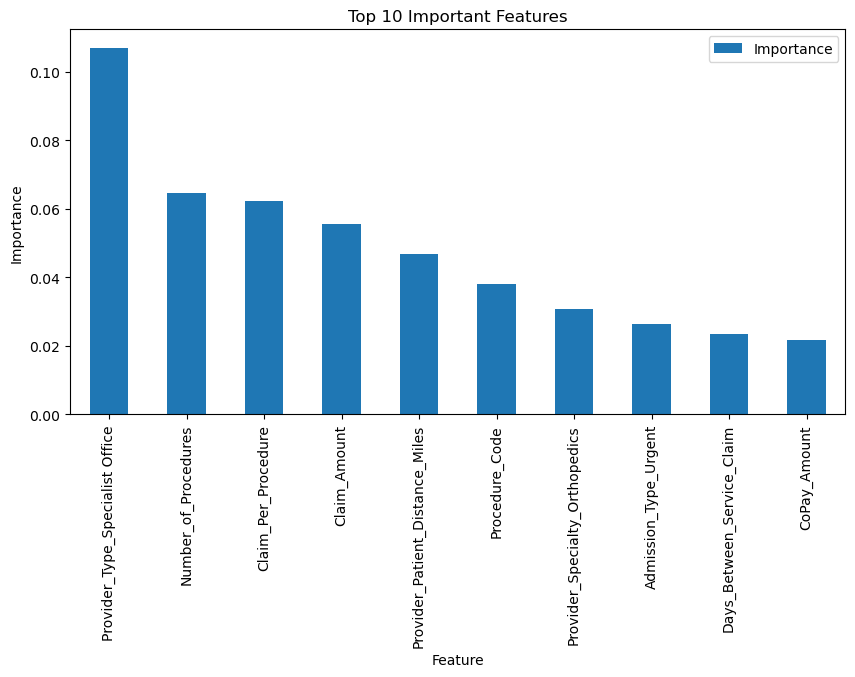

In [51]:
import matplotlib.pyplot as plt

importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()

In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest F1 Score:")
print(grid.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best F1 Score:
0.8982616983788709


In [53]:
best_rf = grid.best_estimator_

best_rf.fit(X_train_smote, y_train_smote)

final_pred = best_rf.predict(X_test)
final_prob = best_rf.predict_proba(X_test)[:,1]

In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_pred)

print(cm)

[[2909  109]
 [ 463  534]]


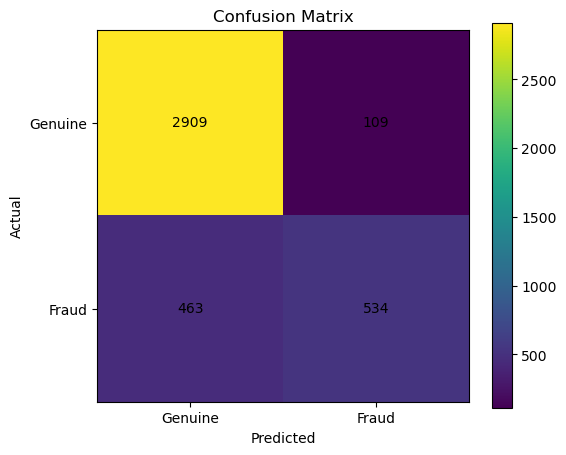

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks([0,1], ['Genuine','Fraud'])
plt.yticks([0,1], ['Genuine','Fraud'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha='center',
                 va='center')

plt.show()

In [56]:
from sklearn.metrics import roc_curve, roc_auc_score

auc = roc_auc_score(y_test, final_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8488261338023346


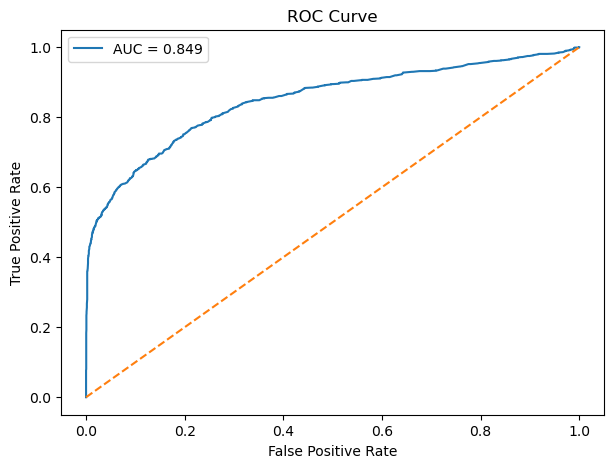

In [57]:
fpr, tpr, thresholds = roc_curve(y_test, final_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr,
         label=f"AUC = {auc:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [58]:
import joblib

joblib.dump(best_rf, "fraud_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [59]:
import joblib

model = joblib.load("fraud_model.pkl")

print(model)

RandomForestClassifier(n_estimators=300, random_state=42)


In [60]:
df_dashboard = df.copy()

# Prepare X exactly as used during training
X_dashboard = df.drop("Is_Fraudulent", axis=1)

X_dashboard = pd.get_dummies(X_dashboard, drop_first=True)

X_dashboard = X_dashboard.reindex(
    columns=X.columns,
    fill_value=0
)

df_dashboard["Predicted_Fraud"] = model.predict(X_dashboard)

df_dashboard["Fraud_Probability"] = model.predict_proba(X_dashboard)[:, 1]

In [61]:
df_dashboard.to_csv("dashboard_data.csv", index=False)

print("Dashboard dataset created successfully!")

Dashboard dataset created successfully!


In [63]:
# -----------------------------
# Prepare input exactly like training
# -----------------------------

def prepare_data(data):

    data = data.copy()

    # remove target columns
    data = data.drop(
        columns=[
            "Predicted_Fraud",
            "Fraud_Probability",
            "Is_Fraudulent"
        ],
        errors="ignore"
    )


    # same encoding used in training
    data = pd.get_dummies(
        data,
        drop_first=True
    )


    # match RandomForest training features
    model_features = model.feature_names_in_


    data = data.reindex(
        columns=model_features,
        fill_value=0
    )


    return data



# -----------------------------
# Test Prediction
# -----------------------------

sample = df.iloc[[0]]

sample_ready = prepare_data(sample)


prediction = model.predict(sample_ready)[0]

probability = model.predict_proba(sample_ready)[0][1]


print("Prediction:", prediction)

print(
    "Fraud Probability:",
    probability*100,
    "%"
)

Prediction: 0
Fraud Probability: 2.9 %
